---
cdt: 2024-09-02T12:00:00
title: "Zhang GC-MS PARAFAC2 with Scaling and Centering"
description: "I have been trying to interpret the PARAFAC2 model results as implemented by TensorLy, however one thing that has been confusing me is whether to standardise the input data. This notebook will investigate the effects of standardisation on decomposition results"
project: parafac2
conclusion: ''
status: open
---


# Prepare Data

25


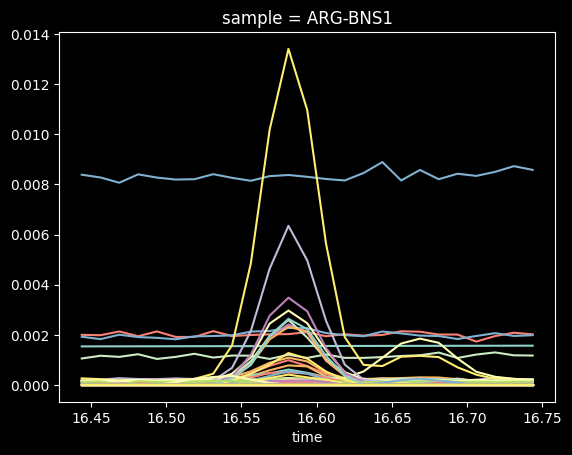

In [1]:
# environment
from tensorly.decomposition import parafac2
import numpy as np
import xarray as xr
from pymatreader import read_mat
from tensorly.parafac2_tensor import apply_parafac2_projections

path = "/Users/jonathan/mres_thesis/pca_analysis/Wine_v7.mat"

# keys have to be in this order to parse the data correctly
key_it = ["Label_Wine_samples", "Label_Elution_time", "Label_Mass_channels"]
data = read_mat(filename=path, variable_names=["Data_GC"] + key_it)
data.keys()

raw_data = xr.DataArray(
    data["Data_GC"],
    coords=[data[k] for k in key_it],
    dims=[
        "sample",
        "time",
        "mz",
    ],
).transpose("time", "mz", "sample")
raw_data.coords

# adjusting the indexes to center the peaks

times = data["Label_Elution_time"]

time_start = 16.52
time_end = 16.76

idx_start = np.nonzero(np.isclose(times, time_start, atol=1e-2))[0][0] - 6
idx_end = np.nonzero(np.isclose(times, time_end, atol=1e-2))[0][0]
print(idx_end - idx_start)
time_start = times[idx_start]
time_end = times[idx_end]

sliced_data = raw_data[idx_start:idx_end, :, :]
sliced_data.coords
sliced_data.isel(sample=0).plot.line(x="time", add_legend=False);


# Standardisation of Tensors

So both Harshmann and Kiers talk about a mean centered and normalised B/F. But how does one do that? Its per slice [@kiers_parafac2parti_1999, p. 3 , line 8]. So how does one perform it within the framework of xarray?

## Mean Centering

In [2]:
mean_spectrum = sliced_data.mean("mz")
mean_spectrum.head(3)


<xarray.DataArray (time: 3, sample: 3)> Size: 72B
array([[8.28241824e-05, 8.57448036e-05, 9.51946068e-05],
       [8.40251487e-05, 8.55716596e-05, 9.51631111e-05],
       [8.27231124e-05, 8.86381144e-05, 9.52857149e-05]])
Coordinates:
  * sample   (sample) <U8 96B 'ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1'
  * time     (time) float64 24B 16.44 16.46 16.47

which gives us a mean value for each time and each sample. We can rationalise that by selecting a fiber and directly calculating its mean.

In [3]:
check_mean_1 = sliced_data.isel(time=0, sample=0).mean()
check_mean_1


<xarray.DataArray ()> Size: 8B
np.float64(8.28241823816205e-05)
Coordinates:
    sample   <U8 32B 'ARG-BNS1'
    time     float64 8B 16.44

In [4]:
check_mean_2 = mean_spectrum.isel(time=0, sample=0)
check_mean_2


<xarray.DataArray ()> Size: 8B
array(8.28241824e-05)
Coordinates:
    sample   <U8 32B 'ARG-BNS1'
    time     float64 8B 16.44

In [5]:
# accounting for floating point errors..
np.isclose(check_mean_1, check_mean_2)


np.True_

Then we should be able to simply subtract one from the other..

In [6]:
mean_centered = sliced_data - mean_spectrum
mean_centered.head(3)


<xarray.DataArray (time: 3, mz: 3, sample: 3)> Size: 216B
array([[[ 1.45487382e-03,  1.53088720e-03,  1.25088235e-03],
        [-8.28241824e-05, -8.57448036e-05, -9.51946068e-05],
        [-8.28241824e-05, -8.57448036e-05, -9.51946068e-05]],

       [[ 1.45482059e-03,  1.53226699e-03,  1.25191894e-03],
        [-8.40251487e-05, -8.55716596e-05, -9.51631111e-05],
        [-8.40251487e-05, -8.55716596e-05, -9.51631111e-05]],

       [[ 1.45727036e-03,  1.53040719e-03,  1.25280143e-03],
        [-8.27231124e-05, -8.86381144e-05, -9.52857149e-05],
        [-8.27231124e-05, -8.86381144e-05, -9.52857149e-05]]])
Coordinates:
  * sample   (sample) <U8 96B 'ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1'
  * time     (time) float64 24B 16.44 16.46 16.47
  * mz       (mz) float64 24B 5.0 6.0 7.0

and then to verify, the spectrum-wise means should be zero.

In [7]:
mean_centered.mean("mz").head(3)


<xarray.DataArray (time: 3, sample: 3)> Size: 72B
array([[-1.10182046e-19, -2.78775484e-19,  1.85263046e-19],
       [-3.42743412e-19, -8.22638398e-20,  3.29732986e-19],
       [-2.35678447e-19, -1.82145965e-19, -1.33221342e-19]])
Coordinates:
  * sample   (sample) <U8 96B 'ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1'
  * time     (time) float64 24B 16.44 16.46 16.47

Hmm. floating point errors?

In [8]:
(abs(mean_centered.mean("mz").round(9)) == 0).all().item()


True

Ok, it's centered. Now for normalisation. ~To do this, replace the previous operation with the scikit learn standard scaler and move this into its own notebook~ Using scikits preprocessing classes may be difficult given the n-dimensional nature of the data. Easier just to calculate the transformation tensor directly.

In [9]:
mean_centered.head(3)


<xarray.DataArray (time: 3, mz: 3, sample: 3)> Size: 216B
array([[[ 1.45487382e-03,  1.53088720e-03,  1.25088235e-03],
        [-8.28241824e-05, -8.57448036e-05, -9.51946068e-05],
        [-8.28241824e-05, -8.57448036e-05, -9.51946068e-05]],

       [[ 1.45482059e-03,  1.53226699e-03,  1.25191894e-03],
        [-8.40251487e-05, -8.55716596e-05, -9.51631111e-05],
        [-8.40251487e-05, -8.55716596e-05, -9.51631111e-05]],

       [[ 1.45727036e-03,  1.53040719e-03,  1.25280143e-03],
        [-8.27231124e-05, -8.86381144e-05, -9.52857149e-05],
        [-8.27231124e-05, -8.86381144e-05, -9.52857149e-05]]])
Coordinates:
  * sample   (sample) <U8 96B 'ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1'
  * time     (time) float64 24B 16.44 16.46 16.47
  * mz       (mz) float64 24B 5.0 6.0 7.0

## Normalisation

In [10]:
# divide the tensor by the spectrum-wise variance.
standardized = mean_centered / mean_centered.std("mz")
standardized.head(3)


<xarray.DataArray (time: 3, mz: 3, sample: 3)> Size: 216B
array([[[ 2.29395365,  2.43615873,  1.70939979],
        [-0.13059197, -0.13644895, -0.13008869],
        [-0.13059197, -0.13644895, -0.13008869]],

       [[ 2.32292273,  2.39306738,  1.69141473],
        [-0.13416357, -0.1336443 , -0.12857086],
        [-0.13416357, -0.1336443 , -0.12857086]],

       [[ 2.36050978,  2.31468159,  1.68242254],
        [-0.13399622, -0.13406171, -0.12796189],
        [-0.13399622, -0.13406171, -0.12796189]]])
Coordinates:
  * sample   (sample) <U8 96B 'ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1'
  * time     (time) float64 24B 16.44 16.46 16.47
  * mz       (mz) float64 24B 5.0 6.0 7.0

In [11]:
standardized.var("mz").head(3)


<xarray.DataArray (time: 3, sample: 3)> Size: 72B
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])
Coordinates:
  * sample   (sample) <U8 96B 'ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1'
  * time     (time) float64 24B 16.44 16.46 16.47

Ok, the tensor is now standardised such that the spectrum-wise mean is 0 and variance is 1. Now to fit the model.

# PARAFAC2 on Standardised Data

In [12]:
best_err = np.inf
decomposition = None

true_rank = 3

for run in range(1):
    print(f"Training model {run}...")
    trial_decomposition, trial_errs = parafac2(
        standardized.to_numpy(),
        true_rank,
        return_errors=True,
        tol=1e-8,
        n_iter_max=500,
        random_state=run,
        verbose=True,
    )
    print(f"Number of iterations: {len(trial_errs)}")
    print(f"Final error: {trial_errs[-1]}")
    if best_err > trial_errs[-1]:
        best_err = trial_errs[-1]
        err = trial_errs
        decomposition = trial_decomposition
    print("-------------------------------")
print(f"Best model error: {best_err}")


Training model 0...
Starting iteration 0
reconstruction error=0.17018918697421975
iteration 1, reconstruction error: 0.15954459159120402, decrease = 0.010644595383015737, unnormalized = 74.75631321522297
iteration 2, reconstruction error: 0.15824586017735803, decrease = 0.0012987314138459827, unnormalized = 74.14777881498027
iteration 3, reconstruction error: 0.1572938735931665, decrease = 0.0009519865841915442, unnormalized = 73.70171538810547
iteration 4, reconstruction error: 0.1564765494132141, decrease = 0.0008173241799523945, unnormalized = 73.31874946124127
PARAFAC2 reconstruction error=0.16274047516401377
Starting iteration 1
reconstruction error=0.1428991365640075
iteration 1, reconstruction error: 0.1416573818099598, decrease = 0.001241754754047697, unnormalized = 66.3837428518837
iteration 2, reconstruction error: 0.1405719090859457, decrease = 0.0010854727240141027, unnormalized = 65.87506662715751
iteration 3, reconstruction error: 0.13942894928054436, decrease = 0.0011429

In [13]:
best_err


np.float64(0.06907510146111409)

In [14]:
weights, factors = apply_parafac2_projections(decomposition)

factors_0, evolving_factor, factors_1 = factors


So I'm still hunting for D_i. I expect there to be a diagonal matrix R x R for each "frontal slice".

factors_1 contains negative values, doesnt look likely. Maybe that's a result of the centering?

# Without Standardisation

Comparing the results of the standardised tensor against the raw tensor will decide if standardisation is beneficial. The gut says yes.

In [15]:
def fit_parafac_model(data, true_rank, runs: int = 1, nn_modes=None):
    best_err = np.inf
    decomposition = None

    for run in range(runs):
        print(f"Training model {run}...")
        trial_decomposition, trial_errs = parafac2(
            data,
            true_rank,
            return_errors=True,
            tol=1e-8,
            n_iter_max=500,
            random_state=run,
            nn_modes=nn_modes,
        )
        print(f"Number of iterations: {len(trial_errs)}")
        print(f"Final error: {trial_errs[-1]}")
        if best_err > trial_errs[-1]:
            best_err = trial_errs[-1]
            err = trial_errs
            decomposition = trial_decomposition
        print("-------------------------------")
    print(f"Best model error: {best_err}")

    return decomposition, best_err


wo_std = {}
wo_std["decomp"], wo_std["err"] = fit_parafac_model(
    sliced_data.to_numpy(), runs=5, true_rank=3
)


Training model 0...
Number of iterations: 500
Final error: 0.06585474199132463
-------------------------------
Training model 1...
Number of iterations: 500
Final error: 0.0658760739813709
-------------------------------
Training model 2...
Number of iterations: 500
Final error: 0.06589190120778114
-------------------------------
Training model 3...
Number of iterations: 500
Final error: 0.06594176705447143
-------------------------------
Training model 4...
Number of iterations: 500
Final error: 0.06577628013431956
-------------------------------
Best model error: 0.06577628013431956


In [16]:
# With Standardisation

with_std = {}
with_std["decomp"], with_std["err"] = fit_parafac_model(
    standardized.to_numpy(), runs=5, true_rank=3
)


Training model 0...
Number of iterations: 500
Final error: 0.06907510146111409
-------------------------------
Training model 1...
Number of iterations: 500
Final error: 0.06892181286092404
-------------------------------
Training model 2...
Number of iterations: 500
Final error: 0.06891036485557109
-------------------------------
Training model 3...
Number of iterations: 500
Final error: 0.0689807866732374
-------------------------------
Training model 4...
Number of iterations: 500
Final error: 0.06895244266703104
-------------------------------
Best model error: 0.06891036485557109


Is the error of the standardised fit less than without?

In [17]:
with_std["err"] < wo_std["err"]


np.False_

No, the standardisation actually produces a greater (marginally) model error than the raw data. That is a surpising result.

# Fit with Non-Negativity


A non-negativity constraint on the spectrum and sample modes would be ideal as it would reduce the total size of the solution space. 

Earlier I stated that you cannot apply non-negativity in the tensorly implementation of PARAFAC2, however I was wrong. You CAN apply non-negativity to modes, just not mode 1, which tensorly calls mode 'B' (are they using C ordering?)

In [18]:
wo_std_nn = {}
wo_std_nn['decomp'], wo_std['err'] = 


SyntaxError: invalid syntax (3320083828.py, line 2)

However, the error does not seem overly affected by the non-negativity constraint..

# Where are the Component Concentrations

TensorLy's PARAFAC2 implementation returns an object with a number of matrices and arrays (lists) of matrices. It is not clear to me, however, where the concentrations of each component are kept.

In [ ]:
wo_std_nn["proj_decomp"] = apply_parafac2_projections(wo_std_nn["decomp"])


In [ ]:
plt.plot(wo_std_nn["proj_decomp"][1][2])


In [ ]:
len(wo_std_nn["proj_decomp"])


I think this is it. According to the docs of the "apply projections" function <http://tensorly.org/stable/_modules/tensorly/parafac2_tensor.html#parafac2_to_tensor>, this element is the C matrix.

I'm a tad tired now, continue this train of thought tomorrow. Preferably with data where you know the compound (component) concentrations beforehand.

In [ ]:
wo_std_nn["decomp"][2][0].shape


Now, a useful test to confirm my suspicison would be to compare my calculated concentrations to the experimental values from the GC-MS dataset publication. If Zhang hasn't included it, maybe the original publication did.

Before we look for the precise figures, we can observe this figure taken from @zhang_flexibleimplementationtrilinearity_2022 of the decomposition of the dataset. Note that the y axes for the plots ofthe third column are marked concentration, and the x axes are samples. This is all the proof I need that my interpretation has been correct. The rows of $A$ are the concentrations of each compound of each rank.

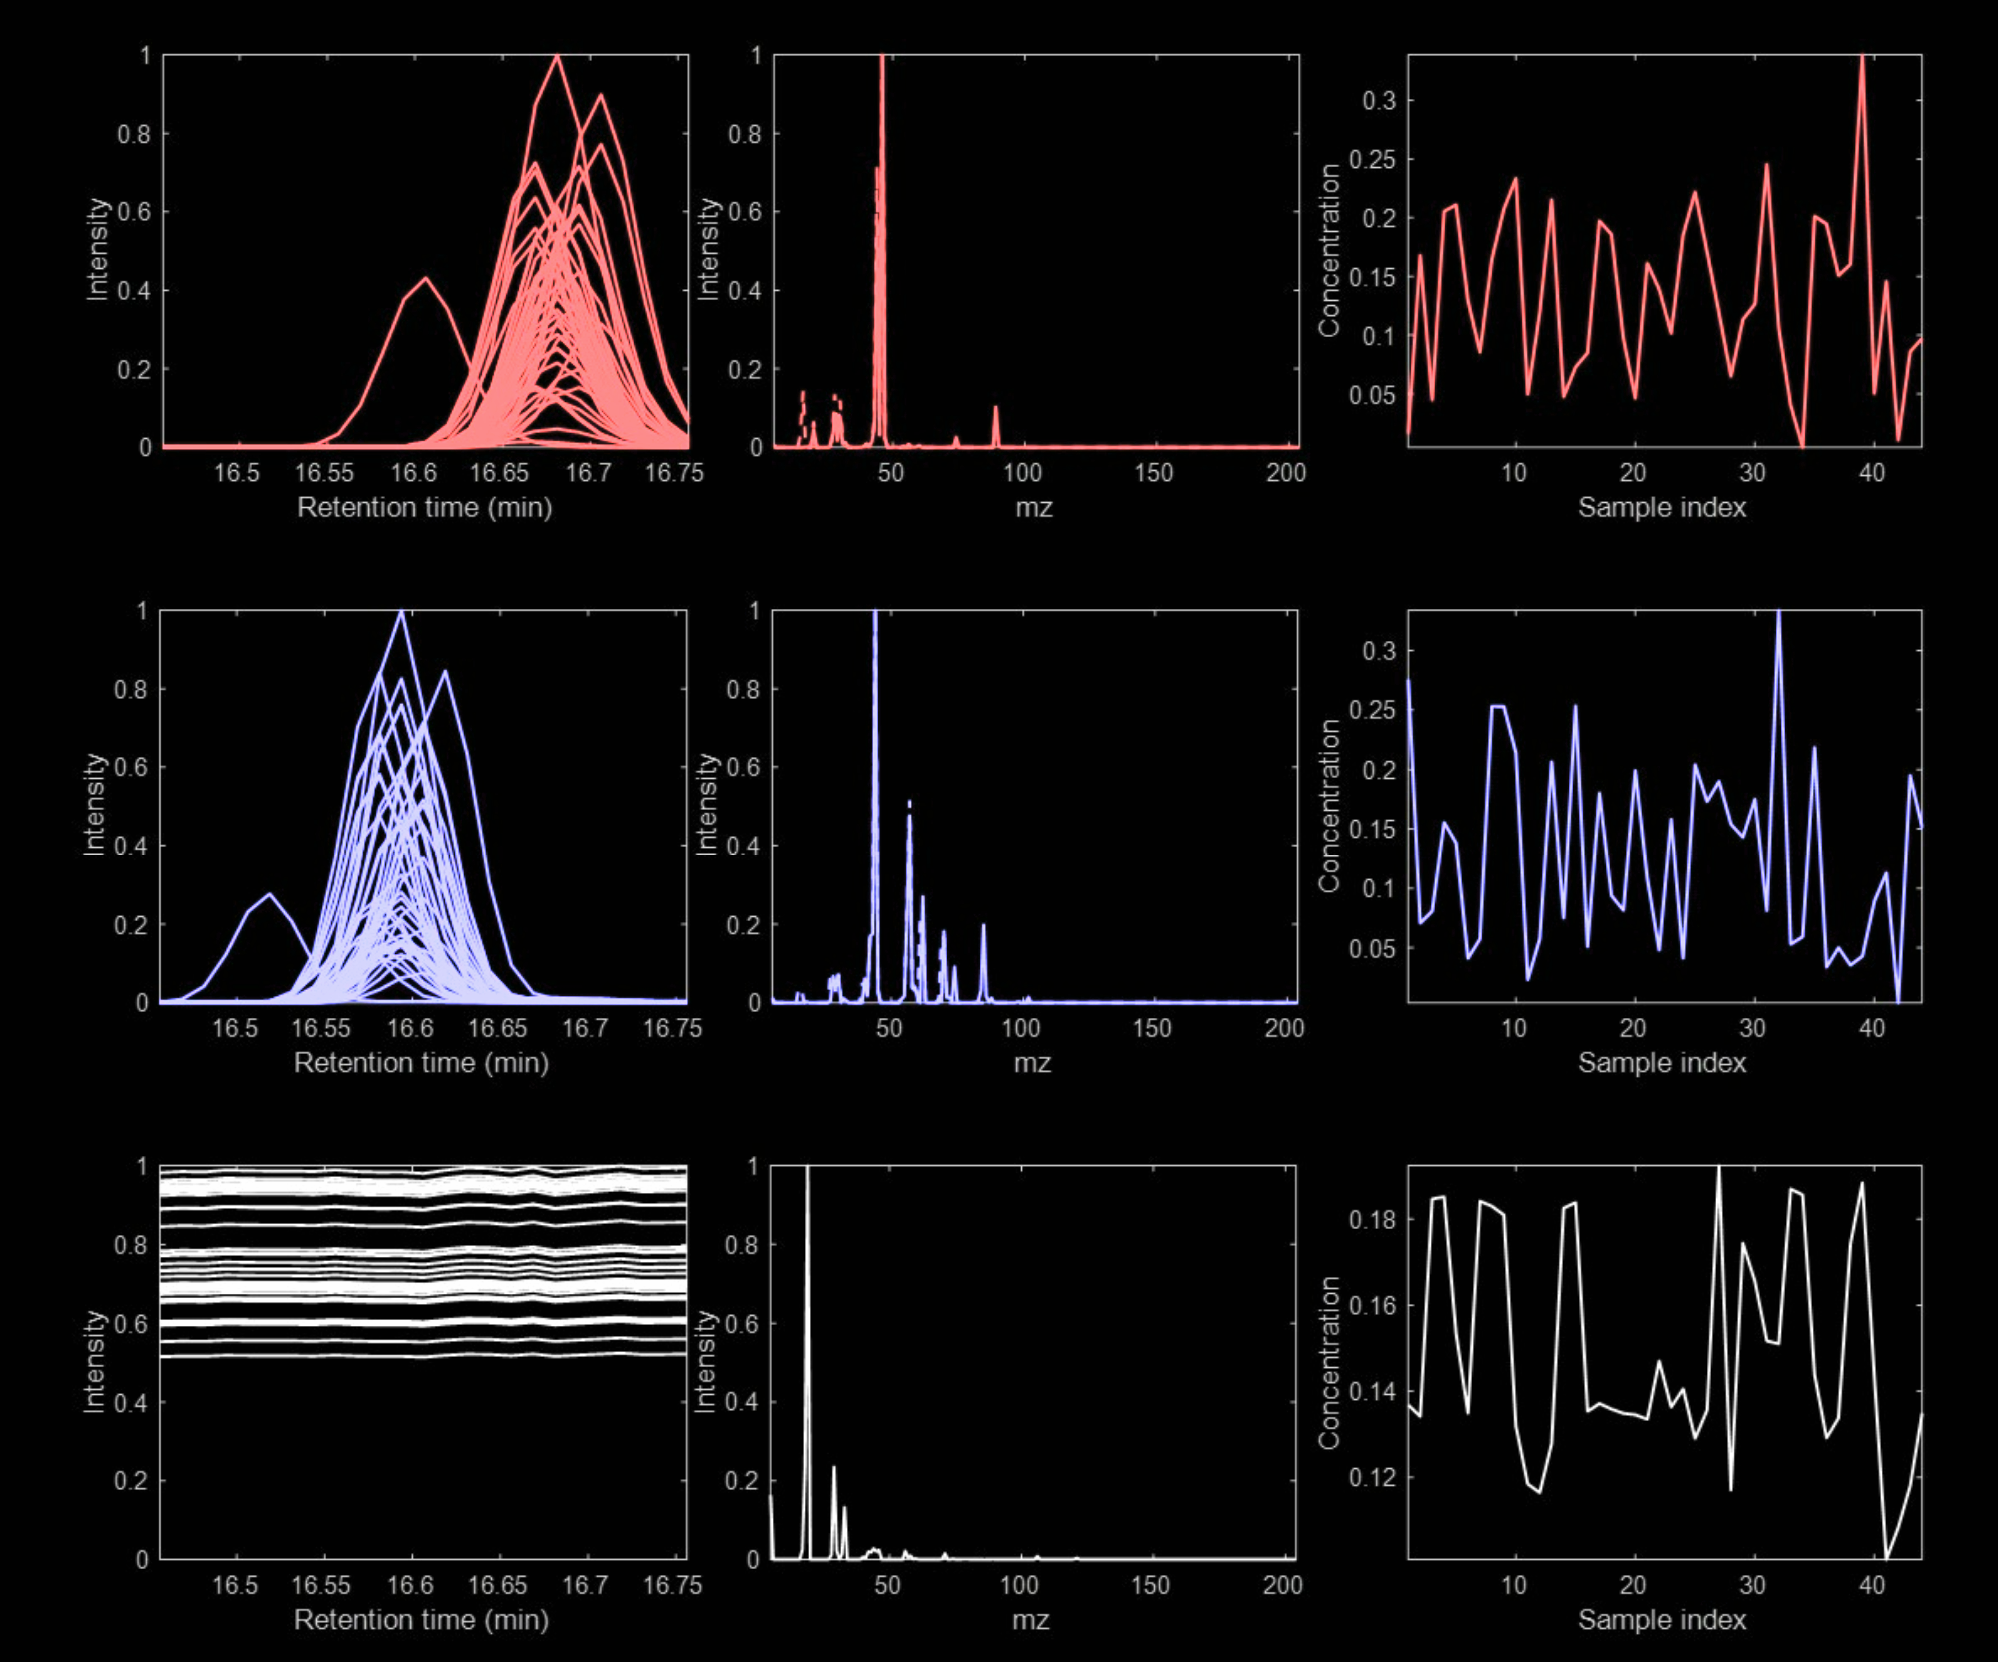